# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Evelyn Chen

**ID**: ec877

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [52]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE_4750/bee4750-hw1-ec8771`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [53]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [81]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [86]:
function minimum_new(array)
    # initialize the minimum value counter
    min_value = array[1] # min value is the first element in the array
    # update minimum values
    for i in 2:length(array) # modified the range to start from the second element
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum_new(array_values);


minimum_new(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

The error: With the original code, the function will not work correctly if all the elements in the array parameter are positive values (AKA greater than 0). Thus, I modified the min_value to take on the first element in the array. NOTE: Because minimum() is already a function in Julia and running minimum(array) was not working, I modified the function name to be minimum_new. 

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [48]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average

function class_average(grades)
  average_grade = mean(grades) # modified student_grades to grades
  return average_grade
end

@show class_average(student_grades);

class_average(student_grades) = 94.4


What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

The error: Since the given parameter is grades, the function should refer to the parameter as grades, not student_grades. Thus, I modified the name in the function from student_grades to grades. In addition, I modified the @show average_grade to @show class_average(student_grades) to actually run the function and refer to the array student_grades in Main.


#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [77]:
# function to simulate a passadieci roll: 3 6-sided dice

function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials) # modified zero() to zeros() function
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) >= 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.493


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

The error: This MethodError is occurring because the arguments do not match the method's requried type parameters. The code is attempting to retrieve/set an index of a type that is not index-based (eg. outcomes, after using zero(), is a numerical value, not an array. I modified the zero() function to the zeros() function instead, ensuring that outcomes is an array of 1000 zeros, not just the value zero.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [83]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
        
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector

    # created for loop to individually remove mean from each component in array
    for i in 1:length(vect) # iterate through the array
        vect[i] = vect[i] - m # remove m from each element
    end
    return vect
end

random_vect = rand(1_000)
print()
@show remove_mean(random_vect)

remove_mean(random_vect) = [-0.48714201347384456, -0.12269216958726825, 0.4548715202104274, -0.028396677324517006, 0.34088759745318487, 0.08368502890520746, -0.3128216458197546, -0.3745114360039007, -0.21849086424244257, -0.40528185357328106, -0.28556783229938687, 0.468680463619218, -0.300790028683001, -0.20952041480451256, 0.35311012601272995, 0.1571804162488315, 0.29888873193645404, -0.11238194768236232, -0.3859918469522362, -0.08067362943634038, -0.4224255064298773, 0.22568452805139905, -0.07065480332076535, -0.04785543152138816, 0.2837802179198743, -0.27000743069327526, 0.04882550115228812, 0.16025664259571182, 0.32274973315765476, 0.46482176159768407, -0.2846132636965564, -0.4705365840931567, -0.19364144734834576, -0.08071506699006381, 0.38333514271463676, 0.42575592258134376, 0.17374899366812113, -0.07104077496796302, -0.25265748749249073, -0.124038341266687, -0.33866817296393337, -0.3237999204667025, -0.3432933944594889, 0.13695788178977097, 0.34771950023061504, 0.19369458059135

1000-element Vector{Float64}:
 -0.48714201347384456
 -0.12269216958726825
  0.4548715202104274
 -0.028396677324517006
  0.34088759745318487
  0.08368502890520746
 -0.3128216458197546
 -0.3745114360039007
 -0.21849086424244257
 -0.40528185357328106
 -0.28556783229938687
  0.468680463619218
 -0.300790028683001
  ⋮
 -0.18892408861150445
 -0.21335847028267252
  0.3136933279009799
  0.33289444587833794
 -0.3110853871612481
 -0.14108229789382365
  0.07444323536705044
 -0.037947383322348704
 -0.2600060456624331
 -0.35557351970923146
  0.07142798070451484
  0.005378492082023456

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

The error: This MethodError is occurring because an operation is used to connect two different types of arguments. In this case, the code is attempting to use an operation to subtract m (a numerical value) from vect (an array). I modified the code to instead iterate through the array (for loop) to subtract m from each individual element in the array.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

Explanation:  $X_1$ represents the amount of wastewater ($\frac{m^3}{day}$) and YUK ($\frac{kg}{m^3}$) sent for land treatment, $X_2$ represents the amount of wastewater ($\frac{m^3}{day}$) and YUK ($\frac{kg}{m^3}$) sent for chemical treatment, and $X_3$ represents the amount of wastewater ($\frac{m^3}{day}$) and YUK ($\frac{kg}{m^3}$) directly disposed in Pristine Brook. The YUK concentration after undergoing land treatment is $0.2$ $X_1$ $\frac{kg}{m^3}$, and the YUK concentration after undergoing chemical treatment is $0.005 X_2^2 \frac{kg}{m^3}$.

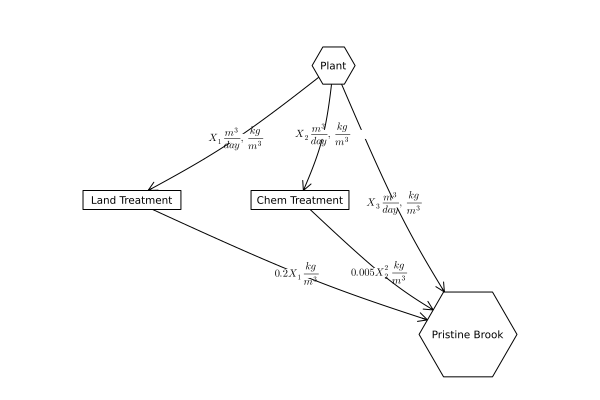

In [ ]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1 \frac{m^3}{day}, \frac{kg}{m^3}", (1,3) => L"X_2 \frac{m^3}{day}, \frac{kg}{m^3}", (1, 4) => L"X_3 \frac{m^3}{day}, \frac{kg}{m^3}",(2, 4) => L"0.2 X_1 \frac{kg}{m^3}",(3, 4) => L"0.005 X_2^2 \frac{kg}{m^3}")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

Before formulating the equations for the treatment cost and amount of YUK discharged into Pristine Brook, the total amount of flow into Pristine Brook is $X_{1} \text{m}^3\text{/day}$ + $X_{2} \text{m}^3\text{/day} $ + $X_{3} \text{m}^3\text{/day}$ = $100$. $X_{1}$ is the amount of wastewater sent to land disposal, $X_{2}$ is the amount of wastewater sent to be chemically treated, and $X_{3}$ is the amount of wastewater sent to Pristine Brook. All of this totals to $100 \text{m}^3\text{/day}$, the amount of wastewater that Cheap Plastic Products, Inc. is producing per day. Since the YUK concentration in the wastewater is $ 1 \frac{kg}{m^3} $, our $\frac{m^3}{day}$ of wastewater and $\frac{kg}{m^3} $ of YUK is a one-to-one ratio.

**Total Amount of YUK discharged into Pristine Brook:**

We need to consider the amount of YUK discharged into Pristine Brook from all three outlets/methods: land treatment, chemical treatment, and direct disposal.

$Y_{land treatment}$ = $0.2X_{1}$. With the land treatment method, 80% of YUK would be removed, so 20% of YUK would remain.

The formula for determining the amount of YUK removed with the chemical treatment method is e($X_{2})$= $1$ - $0.005X_{2}$. With the chemical treatment method, the percentage of YUK is dependent on the amount of YUK being treated, with the efficiency fator being $1$ - $0.005$ $X_2$. Thus, the equation for the amount of YUK remaining after the chemical treatment is $Y_{chemical treatment}$ = $X_2$ ($0.005 X_{2}$) $\Rightarrow$ $Y_{chemical treatment}$ = $0.005 X^2_{2}$.

The third disposal method is directly discharging the YUK into Pristine Brook, which is defined by $Y_{direct}$ = $X_{3}$.

This means the total amount of YUK that is discharged into Pristine Brook is $F(X_{1}, X_{2}, X_{3})$ = $0.2X_{1}$ + $0.005$ $X^2_{2}$ + $X_{3}$.

$F(X_{1}, X_{2}, X_{3})$ $\leq$ $20$ $\frac{kg}{day}$, according to the EPA's standard.

**Total Treatment Cost $F(X_{1}, X_{2}, X_{3})$:**

We can look at the cost of each of the three treatment methods.
For the first treatment method ($Y_{land treatment}$), the daily cost is $\frac{X^2_{1}}{20}$. For the second treatment method ($Y_{chemical treatment}$), the daily cost is $1.5$ $X_{2}$. For the third treatment option ($Y_{direct}$), there are no costs associated, since the power plant is simply discharging the wastewater directly into Pristine Brook.

Thus, the total daily cost function is $F(X_{1}, X_{2}, X_{3})$= $\frac{X^2_{1}}{20}$ + $1.5$ $X_{2}$.



#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [92]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;


# my function starts here
function treatment_plan(X1, X2, X3)

    # part I: calculate the YUK discharge  (kg/day)
    discharge1 = 0.2*X1          
    discharge2 = 0.005*X2^2      
    discharge3 = X3                
    discharge_tot = discharge1 + discharge2 + discharge3 

    # part II: calculate the cost
    cost1 = X1^2/20
    cost2 = 1.5*X2
    cost3 = 0
    cost_tot = cost1 + cost2 + cost3
    
    return (discharge_tot, cost_tot)

end

# test case?
a, b = treatment_plan(55, 40, 5)
@show a;
@show b;


a = 7
b = 10
a = 24.0
b = 211.25


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [ ]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;



a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

See below for the code + plot. According to the graph generated, there are some combinations of wastewater discharge and treatment that do satify the YUK effluent standard as set by the EPA, though the majority of combinations do not. The cost of solutions satisfying the standard range approximately from $280 to $400. The tradeoff between treatment cost and YUK discharge follows an exponential decay trend. The greater the YUK discharge, the lower the cost, which makes logical sense since the land and chemical treatments have costs associated with these two methods, while direct disposal is free. In addtion, the greater the YUK discharge, the fewer treatment plan combinations there are (and the closer the cost ranges are to meet that YUk discharge). To find better solutions, we would have to find a combination that minimizes cost while satisfying the YUK discharge standard, likely through some mathematical constraints and models.

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

The strategy to minimize cost would be to send all wastewater directly to Pristine Brook ($100 \frac{m^3}{day}$), since this is the only free method. This would mean that none of the wastewater undergo the other treatment plans (land treatment and chemical treatment), which do cost money. The strategy to minimize YUk discharge would lkely be to find the combination of treatment plans that is most efficient at filtering out the YUK discharge, AKA a combination of the land treatment and chemical treatment. I began substituting in combinations for both land treatment and chemical treatment, and discovered that $(0.2)(80) + 0.005(20)^2$ equals 18, which is the least amount of YUK discharged. Trying a combination of 81% land treatment + 19% chemical treatment, as well as a combination of 79% land treatment and 21% chemical treatment gives us a greater YUK discharge amount, so 80% landtreatment and 20% chemical treatment is the most efficient combination in minimizing YUK discharge. See plot to view the values of both strategies. These values are at the extreme ends of the spread of values in the graph. While it is more ethical to select the option that minimizes YUK discharge over minimizing cost, the most ideal option would be to find the least expensive combination that would still satisfy the EPA effluent standard (estimated to be roughly $280, according to the graph).

## References

List any external references consulted, including classmates. Other than the references mentioned in this lab, I also consulted documentation on Julia plots (specifically the scatter function and its the vline function, as well as legend markers) for 2.3 and 2.4. I did this by searching up "scatter function," "vline function", "markers color and legend julia" to learn more about their implementation. 

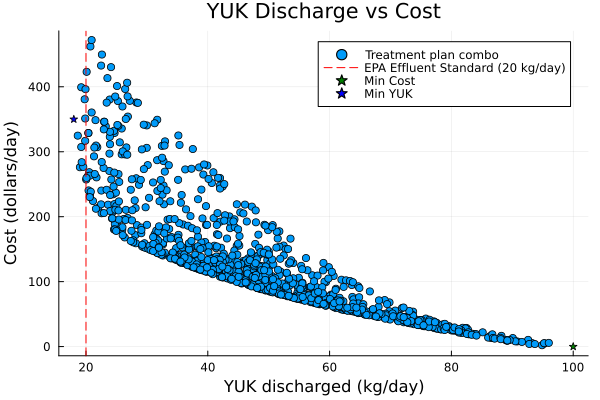

In [106]:
Random.seed!(123) # setting random seed

# sample 1000 different combos from Dirichlet(1,3)
combos = rand(Dirichlet(3, 1.0), 1000) .* 100 # scale it to 100
# note: samples 1000 vectors, 3-D Dirichlet disribution with concentration parameters = 1
# sum to 1 -> sum to 100 


arr_YUK = Float64[]   # store YUK discharges in an array
arr_costs = Float64[]   # store costs in an array

for i in 1:1000
    # pull out the combos by viewing each column while reiterating through the 1000 samples
    X1 = combos[1, i]
    X2 = combos[2, i]
    X3 = combos[3, i]

    YUK, costs = treatment_plan(X1, X2, X3) # run the model
end

# plot results
scatter(Y_vals, C_vals,
    xlabel="YUK discharged (kg/day)",
    ylabel="Cost (dollars/day)",
    title="YUK Discharge vs Cost",
    label="Treatment plan combo")

# add the EPA's effluent standard line (20 kg/day)
vline!([20], color=:red, linestyle=:dash, label="EPA Effluent Standard (20 kg/day)")

# min-cost strategy
minYUK, mincost = treatment_plan(0, 0, 100)
scatter!([minYUK], [mincost], color=:green, marker=:star5, label="Min Cost")

# min-YUK strategy
minYUK, mincost = treatment_plan(80, 20, 0)
scatter!([minYUK], [mincost], color=:blue, marker=:star5, label="Min YUK")

